In [1]:
import os
from typing import List, Dict, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_figura2_metrics_txt(
    folder: str,
    fig_out_ratio: str,
    fig_out_haps: str
) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    """
    Lee múltiples .txt con separador ';' que contienen, además de las columnas base,
    las columnas: ratio_reco y num_haplotypes. Agrega por tiempo con IC95% y genera
    dos figuras (una por métrica).

    Parámetros
    ----------
    folder : str
        Carpeta con los .txt (p. ej. 'results/num_genomes_2').
    fig_out_ratio : str
        Archivo de salida para la figura de 'ratio_reco' (p. ej. 'fig_2a_ratio.jpg').
    fig_out_haps : str
        Archivo de salida para la figura de 'num_haplotypes' (p. ej. 'fig_2b_haps.jpg').

    Retorna
    -------
    Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]
        {'ratio_reco': (x, mean, lo, hi), 'num_haplotypes': (x, mean, lo, hi)}
    """

    # ---------- Helpers ----------
    def load_txt(path: str) -> pd.DataFrame:
        df = pd.read_csv(path, sep=';')
        req = ['time', 'ratio_reco', 'num_haplotypes']
        missing = [c for c in req if c not in df.columns]
        if missing:
            raise ValueError(f"Faltan columnas en {path}: {missing}")
        return df[req].copy()

    def nanmean_ci95(mat: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        mat: shape (n_runs, T) con NaN para padding.
        Devuelve (mean, lo, hi) con IC95% por tiempo.
        """
        m = np.nanmean(mat, axis=0)
        s = np.nanstd(mat, axis=0, ddof=1)
        n = np.sum(~np.isnan(mat), axis=0).astype(float)
        se = np.where(n > 1, s / np.sqrt(n), 0.0)
        ci = 1.96 * se
        return m, m - ci, m + ci

    def stack_runs(series_list: List[np.ndarray]) -> np.ndarray:
        """Apila listas 1D con distinto largo en (n_runs, T_max) con NaN padding."""
        T = max(len(s) for s in series_list)
        M = np.full((len(series_list), T), np.nan, dtype=float)
        for i, s in enumerate(series_list):
            M[i, :len(s)] = s
        return M

    # ---------- Recolección y orden ----------
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"No existe la carpeta: {folder}")

    txt_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".txt")]

    def _suffix_key(path: str):
        base = os.path.basename(path)
        try:
            return (int(base.split("_")[-1].replace(".txt","")), base)
        except Exception:
            return (10**9, base)

    txt_files.sort(key=_suffix_key)

    if len(txt_files) == 0:
        raise FileNotFoundError(f"No se encontraron .txt en la carpeta: {folder}")

    # ---------- Cargar y apilar ----------
    xs = []
    series_ratio = []
    series_haps = []

    for f in txt_files:
        df = load_txt(f)
        xs.append(df['time'].to_numpy())
        series_ratio.append(df['ratio_reco'].to_numpy(dtype=float))
        series_haps.append(df['num_haplotypes'].to_numpy(dtype=float))

    # Eje unificado por padding
    T = max(x.size for x in xs)
    x = np.arange(T)

    M_ratio = stack_runs(series_ratio)
    M_haps  = stack_runs(series_haps)

    mean_r, lo_r, hi_r = nanmean_ci95(M_ratio)
    mean_h, lo_h, hi_h = nanmean_ci95(M_haps)

    # ---------- Figura ratio_reco ----------
    fig1, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.plot(x, mean_r, label='ratio_reco', c = "r")
    ax1.fill_between(x, lo_r, hi_r, alpha=0.2, color = "r")
    ax1.set_title("Ratio de recombinación (IC95%)")
    ax1.set_xlabel("time")
    ax1.set_ylabel("ratio_reco")
    ax1.set_ylim(0., 1.0)     # como pediste
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    plt.tight_layout()
    plt.savefig(fig_out_ratio, dpi=400, bbox_inches="tight")
    plt.show(fig1)
    plt.close(fig1)

    # ---------- Figura num_haplotypes ----------
    fig2, ax2 = plt.subplots(figsize=(7, 4.5))
    ax2.plot(x, mean_h, label='num_haplotypes',c = "b")
    ax2.fill_between(x, lo_h, hi_h, alpha=0.2)
    ax2.set_title("Número de haplotipos (IC95%)")
    ax2.set_xlabel("time")
    ax2.set_ylabel("num_haplotypes")
    #ax2.set_ylim(0, 70)        # como pediste
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.savefig(fig_out_haps, dpi=400, bbox_inches="tight")
    plt.show(fig2)
    plt.close(fig2)

    return {
        'ratio_reco': (x, mean_r, lo_r, hi_r),
        'num_haplotypes': (x, mean_h, lo_h, hi_h)
    }

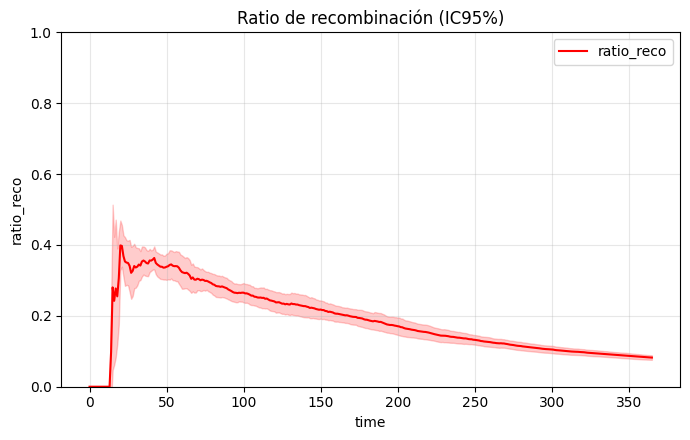

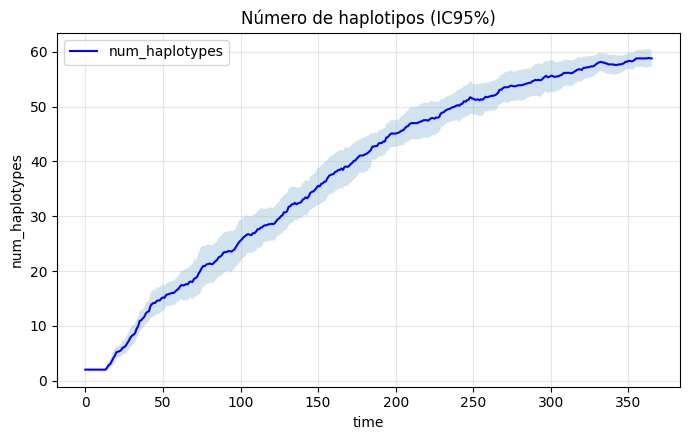

In [2]:
res = plot_figura2_metrics_txt(folder="results/num_genomes_2_bitting_rate_4",
                               fig_out_ratio="fig_2a_ratio_num_genomes_2_bitting_rate_4.jpg",
                               fig_out_haps="fig_2b_num_haplotypes_num_genomes_2_bitting_rate_4.jpg")

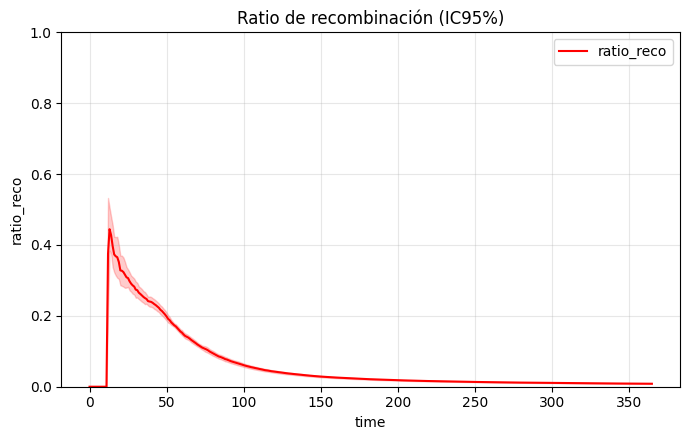

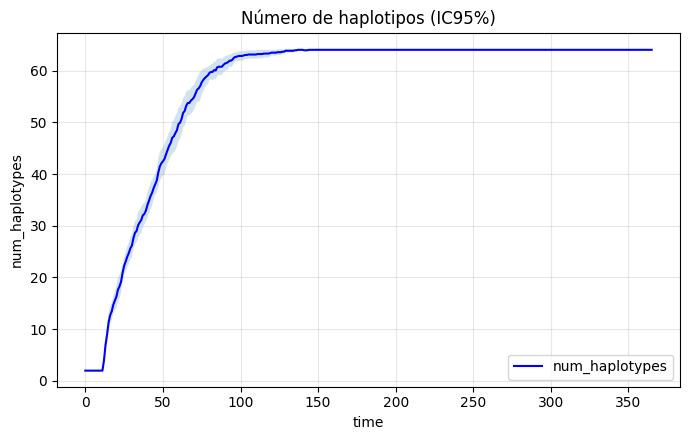

In [3]:
res = plot_figura2_metrics_txt(folder="results/num_genomes_2_bitting_rate_40",
                               fig_out_ratio="fig_2a_ratio_num_genomes_2_bitting_rate_40.jpg",
                               fig_out_haps="fig_2b_num_haplotypes_num_genomes_2_bitting_rate_40.jpg")

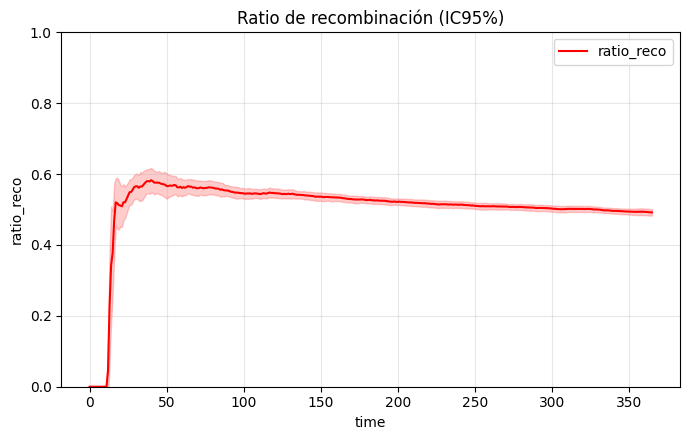

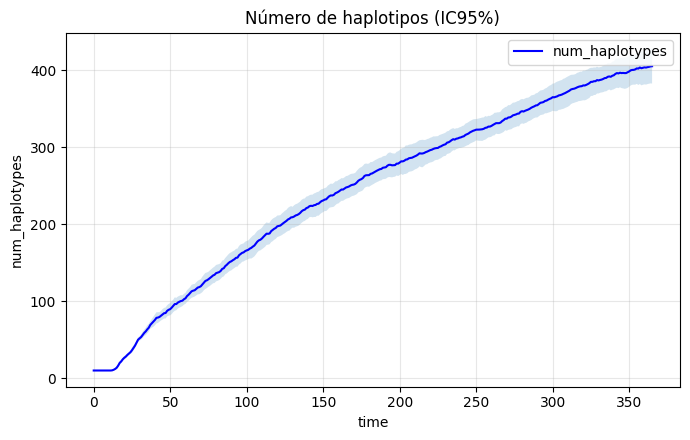

In [4]:
res = plot_figura2_metrics_txt(folder="results/num_genomes_10_bitting_rate_4",
                               fig_out_ratio="fig_2a_ratio_num_genomes_10_bitting_rate_4.jpg",
                               fig_out_haps="fig_2b_num_haplotypes_num_genomes_10_bitting_rate_4.jpg")

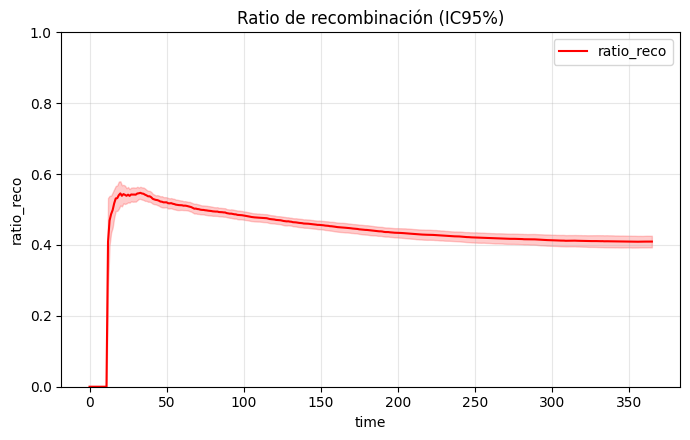

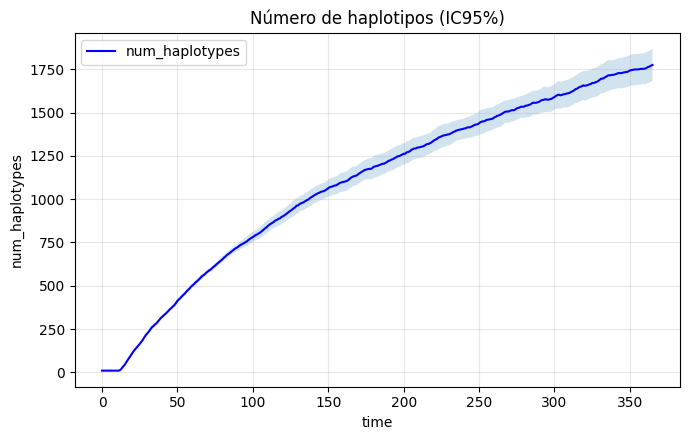

In [5]:
res = plot_figura2_metrics_txt(folder="results/num_genomes_10_bitting_rate_40",
                               fig_out_ratio="fig_2a_ratio_num_genomes_10_bitting_rate_40.jpg",
                               fig_out_haps="fig_2b_num_haplotypes_num_genomes_10_bitting_rate_40.jpg")